Using device: cpu
Dataset: C:\Users\harsh\YuvaIntern_Data_Science_Project\task1_air_quality\outputs\air_quality_cleaned.csv
Output: C:\Users\harsh\YuvaIntern_Data_Science_Project\task5_deep_learning\outputs
Dataset shape: (9357, 13)

Columns:
['Datetime', 'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

First 5 rows:


,Datetime,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2004-03-10 20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2004-03-10 21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,2004-03-10 22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888



Missing values:
Datetime         0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

Data types:
Datetime             str
CO(GT)           float64
PT08.S1(CO)      float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object

Number of samples: 9357
Number of features: 11

Features used:
['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Dataset split:
Training: (5613, 11)
Validation: (1872, 11)
Testing: (1872, 11)

Feature scaling completed.
AirQualityMLP(
  (network): Sequential(
    (0): Linear(in_features=

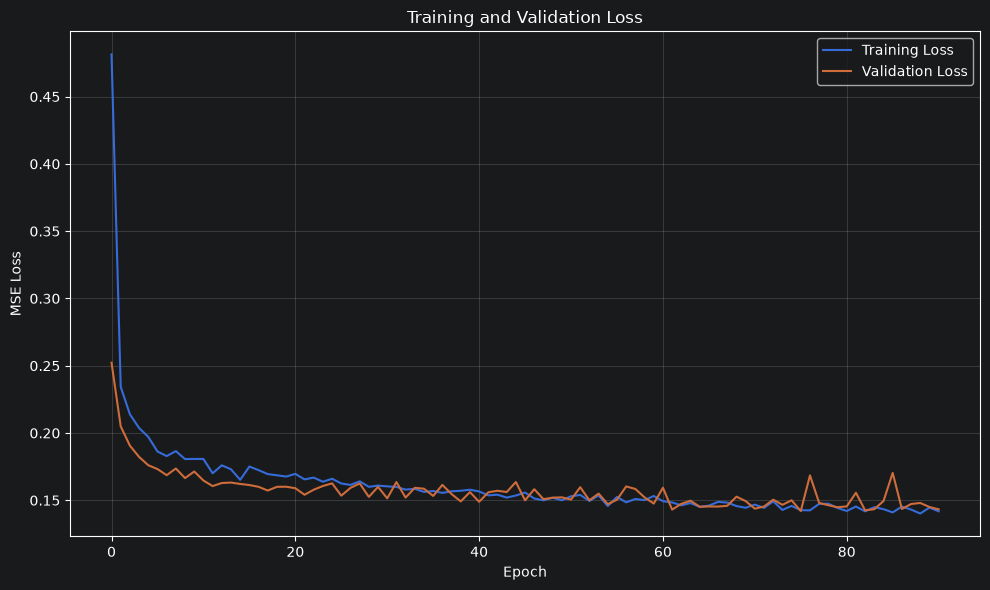

Saved: C:\Users\harsh\YuvaIntern_Data_Science_Project\task5_deep_learning\outputs\figures\training_validation_loss.png

DEEP LEARNING MODEL RESULTS
MAE  : 0.3081
RMSE : 0.4681
R²   : 0.8832

Results saved to:
C:\Users\harsh\YuvaIntern_Data_Science_Project\task5_deep_learning\outputs\deep_learning_results.csv


,Metric,Value
0,MAE,0.308146
1,RMSE,0.468092
2,R2,0.883178


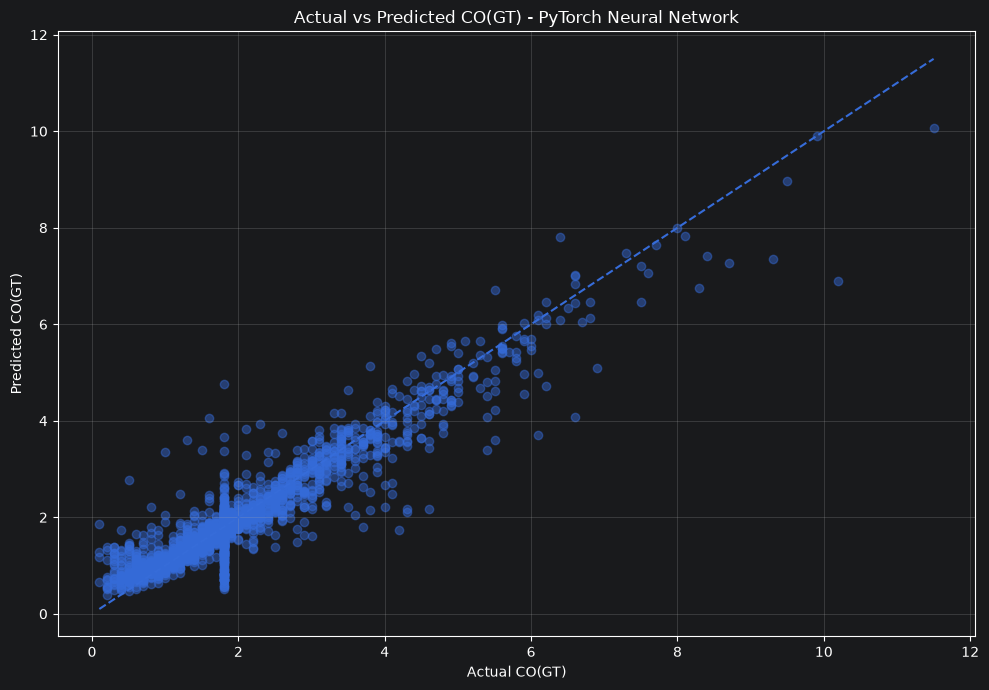

Saved: C:\Users\harsh\YuvaIntern_Data_Science_Project\task5_deep_learning\outputs\figures\actual_vs_predicted_deep_learning.png


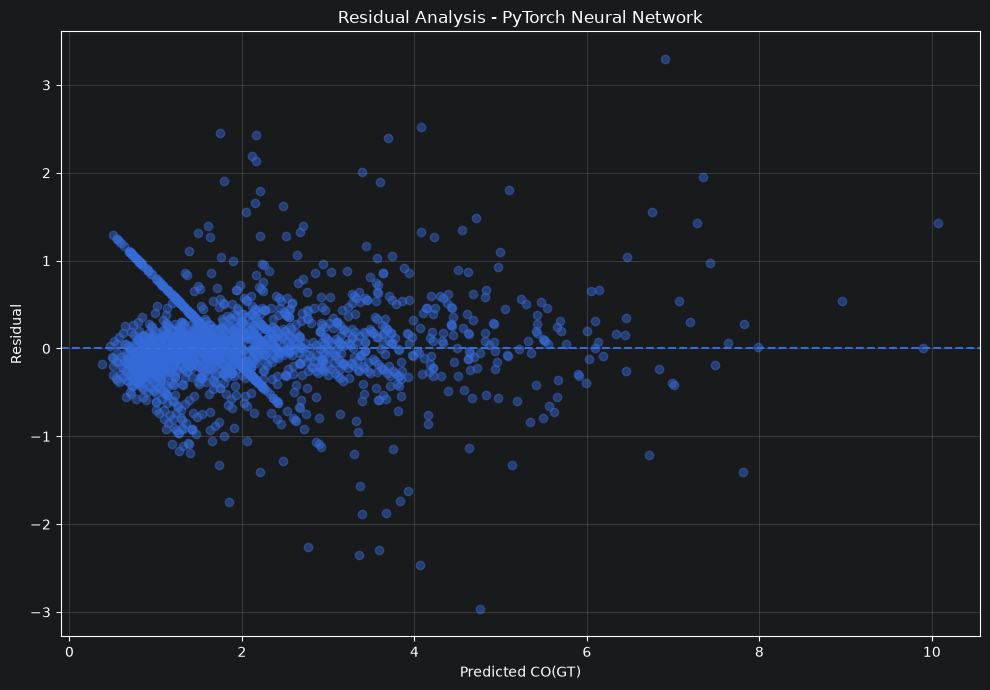

Saved: C:\Users\harsh\YuvaIntern_Data_Science_Project\task5_deep_learning\outputs\figures\residual_analysis_deep_learning.png

Prediction file saved:
C:\Users\harsh\YuvaIntern_Data_Science_Project\task5_deep_learning\outputs\test_predictions.csv


,Actual_CO_GT,Predicted_CO_GT,Residual
0,1.3,1.273776,0.026224
1,1.8,0.841453,0.958547
2,2.6,2.877211,-0.277211
3,3.1,3.270235,-0.170235
4,1.3,1.421397,-0.121397
5,1.8,1.549694,0.250306
6,1.4,1.250454,0.149546
7,1.8,2.080983,-0.280983
8,1.1,1.300980,-0.200980
9,1.0,0.857302,0.142698



TASK 5 DEEP LEARNING SUMMARY
Input features       : 11
Training samples     : 5613
Validation samples   : 1872
Testing samples      : 1872

Architecture:
Input → 64 → 32 → 16 → 1

Hyperparameters:
Batch size           : 64
Learning rate        : 0.001
Maximum epochs       : 100
Optimizer            : Adam
Loss function        : MSELoss
Dropout              : 0.20

Test Performance:
MAE                  : 0.3081
RMSE                 : 0.4681
R²                   : 0.8832

Output files:
C:\Users\harsh\YuvaIntern_Data_Science_Project\task5_deep_learning\outputs\figures\training_validation_loss.png
C:\Users\harsh\YuvaIntern_Data_Science_Project\task5_deep_learning\outputs\figures\actual_vs_predicted_deep_learning.png
C:\Users\harsh\YuvaIntern_Data_Science_Project\task5_deep_learning\outputs\figures\residual_analysis_deep_learning.png
C:\Users\harsh\YuvaIntern_Data_Science_Project\task5_deep_learning\outputs\deep_learning_results.csv
C:\Users\harsh\YuvaIntern_Data_Science_Project\task5_dee

In [1]:
# ============================================================
# TASK 5: DEEP LEARNING APPLICATION IN DATA SCIENCE
# Air Quality - CO(GT) Prediction using PyTorch
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 2. CREATE OUTPUT DIRECTORIES
# ============================================================

BASE_DIR = r"C:\Users\harsh\YuvaIntern_Data_Science_Project"

DATA_PATH = os.path.join(
    BASE_DIR,
    "task1_air_quality",
    "outputs",
    "air_quality_cleaned.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "task5_deep_learning",
    "outputs"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

print("Dataset:", DATA_PATH)
print("Output:", OUTPUT_DIR)


# ============================================================
# 3. LOAD DATASET
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())


# ============================================================
# 4. BASIC DATA CHECK
# ============================================================

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)


# ============================================================
# 5. PREPARE FEATURES AND TARGET
# ============================================================

TARGET = "CO(GT)"

if TARGET not in df.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

# Convert possible infinite values to NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Keep only numeric columns
numeric_df = df.select_dtypes(include=[np.number]).copy()

if TARGET not in numeric_df.columns:
    raise ValueError(
        f"'{TARGET}' is not numeric in the cleaned dataset."
    )

# Remove rows where target is missing
numeric_df = numeric_df.dropna(subset=[TARGET])

# Fill remaining missing numeric values using median
numeric_df = numeric_df.fillna(numeric_df.median(numeric_only=True))

# Features and target
X = numeric_df.drop(columns=[TARGET])
y = numeric_df[TARGET]

print("\nNumber of samples:", len(X))
print("Number of features:", X.shape[1])

print("\nFeatures used:")
print(X.columns.tolist())


# ============================================================
# 6. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# First split: 80% train+validation, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

# Second split: 75% of 80% = 60% total train
# 25% of 80% = 20% total validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=SEED
)

print("\nDataset split:")
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)


# ============================================================
# 7. FEATURE SCALING
# ============================================================

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Scale target separately
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_val_scaled = scaler_y.transform(
    y_val.values.reshape(-1, 1)
)

y_test_scaled = scaler_y.transform(
    y_test.values.reshape(-1, 1)
)

print("\nFeature scaling completed.")


# ============================================================
# 8. CONVERT DATA TO PYTORCH TENSORS
# ============================================================

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_scaled,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val_scaled,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_scaled,
    dtype=torch.float32
)


# ============================================================
# 9. CREATE DATA LOADERS
# ============================================================

BATCH_SIZE = 64

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# ============================================================
# 10. DEFINE NEURAL NETWORK
# ============================================================

class AirQualityMLP(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(

            # Hidden Layer 1
            nn.Linear(input_size, 64),
            nn.ReLU(),

            # Dropout for regularization
            nn.Dropout(0.20),

            # Hidden Layer 2
            nn.Linear(64, 32),
            nn.ReLU(),

            # Hidden Layer 3
            nn.Linear(32, 16),
            nn.ReLU(),

            # Output layer
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


input_size = X_train.shape[1]

model = AirQualityMLP(input_size).to(device)

print(model)


# ============================================================
# 11. LOSS FUNCTION AND OPTIMIZER
# ============================================================

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

print("\nLoss function: MSELoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")


# ============================================================
# 12. TRAINING
# ============================================================

EPOCHS = 100

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None

patience = 15
patience_counter = 0

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_train_loss += (
            loss.item() * X_batch.size(0)
        )

    train_loss = (
        running_train_loss /
        len(train_loader.dataset)
    )

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            running_val_loss += (
                loss.item() * X_batch.size(0)
            )

    val_loss = (
        running_val_loss /
        len(val_loader.dataset)
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # -------------------------
    # Save best model
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

        patience_counter = 0

    else:
        patience_counter += 1

    # -------------------------
    # Progress
    # -------------------------
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1:03d}/{EPOCHS}] "
            f"Train Loss: {train_loss:.5f} | "
            f"Validation Loss: {val_loss:.5f}"
        )

    # -------------------------
    # Early stopping
    # -------------------------
    if patience_counter >= patience:

        print(
            f"\nEarly stopping at epoch {epoch + 1}"
        )

        break


# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("\nTraining completed.")


# ============================================================
# 13. SAVE TRAINED MODEL
# ============================================================

MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "air_quality_mlp.pth"
)

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("Model saved to:")
print(MODEL_PATH)


# ============================================================
# 14. TRAINING / VALIDATION LOSS CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

LOSS_FIG = os.path.join(
    FIGURE_DIR,
    "training_validation_loss.png"
)

plt.savefig(
    LOSS_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", LOSS_FIG)


# ============================================================
# 15. GENERATE TEST PREDICTIONS
# ============================================================

model.eval()

predictions_scaled = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        X_batch = X_batch.to(device)

        predictions = model(X_batch)

        predictions_scaled.extend(
            predictions.cpu().numpy()
        )

predictions_scaled = np.array(
    predictions_scaled
).reshape(-1, 1)

# Convert predictions back to original CO(GT) scale
predictions = scaler_y.inverse_transform(
    predictions_scaled
).flatten()

actual = y_test.values


# ============================================================
# 16. EVALUATION METRICS
# ============================================================

mae = mean_absolute_error(
    actual,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

r2 = r2_score(
    actual,
    predictions
)

print("\n==============================")
print("DEEP LEARNING MODEL RESULTS")
print("==============================")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")


# ============================================================
# 17. SAVE MODEL RESULTS
# ============================================================

results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2"
    ],
    "Value": [
        mae,
        rmse,
        r2
    ]
})

RESULTS_PATH = os.path.join(
    OUTPUT_DIR,
    "deep_learning_results.csv"
)

results.to_csv(
    RESULTS_PATH,
    index=False
)

print("\nResults saved to:")
print(RESULTS_PATH)

display(results)


# ============================================================
# 18. ACTUAL VS PREDICTED PLOT
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(
    actual,
    predictions,
    alpha=0.45
)

min_value = min(
    actual.min(),
    predictions.min()
)

max_value = max(
    actual.max(),
    predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual CO(GT)")
plt.ylabel("Predicted CO(GT)")

plt.title(
    "Actual vs Predicted CO(GT) - PyTorch Neural Network"
)

plt.grid(alpha=0.3)

plt.tight_layout()

PRED_FIG = os.path.join(
    FIGURE_DIR,
    "actual_vs_predicted_deep_learning.png"
)

plt.savefig(
    PRED_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", PRED_FIG)


# ============================================================
# 19. RESIDUAL ANALYSIS
# ============================================================

residuals = actual - predictions

plt.figure(figsize=(10, 7))

plt.scatter(
    predictions,
    residuals,
    alpha=0.45
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted CO(GT)")
plt.ylabel("Residual")

plt.title(
    "Residual Analysis - PyTorch Neural Network"
)

plt.grid(alpha=0.3)

plt.tight_layout()

RESIDUAL_FIG = os.path.join(
    FIGURE_DIR,
    "residual_analysis_deep_learning.png"
)

plt.savefig(
    RESIDUAL_FIG,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", RESIDUAL_FIG)


# ============================================================
# 20. PREDICTION SAMPLE TABLE
# ============================================================

prediction_table = pd.DataFrame({
    "Actual_CO_GT": actual,
    "Predicted_CO_GT": predictions,
    "Residual": residuals
})

PREDICTIONS_PATH = os.path.join(
    OUTPUT_DIR,
    "test_predictions.csv"
)

prediction_table.to_csv(
    PREDICTIONS_PATH,
    index=False
)

print("\nPrediction file saved:")
print(PREDICTIONS_PATH)

display(
    prediction_table.head(20)
)


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n==========================================")
print("TASK 5 DEEP LEARNING SUMMARY")
print("==========================================")

print(f"Input features       : {input_size}")
print(f"Training samples     : {len(X_train)}")
print(f"Validation samples   : {len(X_val)}")
print(f"Testing samples      : {len(X_test)}")

print("\nArchitecture:")
print(f"Input → 64 → 32 → 16 → 1")

print("\nHyperparameters:")
print(f"Batch size           : {BATCH_SIZE}")
print(f"Learning rate        : 0.001")
print(f"Maximum epochs       : {EPOCHS}")
print(f"Optimizer            : Adam")
print(f"Loss function        : MSELoss")
print(f"Dropout              : 0.20")

print("\nTest Performance:")
print(f"MAE                  : {mae:.4f}")
print(f"RMSE                 : {rmse:.4f}")
print(f"R²                   : {r2:.4f}")

print("\nOutput files:")
print(LOSS_FIG)
print(PRED_FIG)
print(RESIDUAL_FIG)
print(RESULTS_PATH)
print(MODEL_PATH)
print(PREDICTIONS_PATH)

